## BLOQUE 0 — Configuración Local y GPU

In [1]:
import subprocess
import sys
import os
import tensorflow as tf

# ── Detección de dispositivos ──────────────────────────────────
gpus  = tf.config.list_physical_devices("GPU")
cpus  = tf.config.list_physical_devices("CPU")

print(f"TensorFlow : {tf.__version__}")
print(f"CPUs       : {len(cpus)}")
print(f"GPUs (CUDA): {len(gpus)}")

# Intel Iris Xe es una GPU integrada que comparte la RAM del sistema.
# TensorFlow estándar usa CUDA (exclusivo de NVIDIA), por lo que
# el entrenamiento se ejecutará en CPU — con 64 GB de RAM y
# paralelismo multi-hilo esto es perfectamente viable.
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print(f"Memory growth: {e}")
    print("GPU CUDA detectada — memory growth activado.")
else:
    print("No se detectó GPU CUDA → entrenando en CPU.")
    # Dejar que TF use todos los núcleos disponibles automáticamente
    tf.config.threading.set_intra_op_parallelism_threads(0)
    tf.config.threading.set_inter_op_parallelism_threads(0)

print(f"Dispositivo activo: {tf.config.list_logical_devices()}")
print("Entorno local configurado.")


TensorFlow : 2.15.0
CPUs       : 1
GPUs (CUDA): 0
No se detectó GPU CUDA → entrenando en CPU.
Dispositivo activo: [LogicalDevice(name='/device:CPU:0', device_type='CPU')]
Entorno local configurado.


## BLOQUE 1 — Importaciones

In [2]:
import os, warnings, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from pathlib import Path
import itertools


warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
print(f"TensorFlow: {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.15.0
GPUs: []


## BLOQUE 2 — Configuración Central

In [3]:
RUTA_BASE       = os.getcwd()  # Ejecutar desde c:/Users/Dell/Desktop/hackathon-sala
RUTA_DATASET    = os.path.join(RUTA_BASE, "Data_M1")
RUTA_MODELOS    = os.path.join(RUTA_BASE, "modelos")
RUTA_RESULTADOS = os.path.join(RUTA_BASE, "resultados")
RUTA_ALL   = os.path.join(RUTA_DATASET, "all")

os.makedirs(RUTA_MODELOS, exist_ok=True)
os.makedirs(RUTA_RESULTADOS, exist_ok=True)

CFG = {
    "train_dir":    os.path.join(RUTA_DATASET, "train"),
    "valid_dir":    os.path.join(RUTA_DATASET, "valid"),
    "test_dir":     os.path.join(RUTA_DATASET, "test"),

    "modelo_best":  os.path.join(RUTA_MODELOS, "m1_validador_best.keras"),
    "modelo_final": os.path.join(RUTA_MODELOS, "m1_validador_FINAL.keras"),
    "resultados_dir": RUTA_RESULTADOS,

    # banana_leaf=0, non_banana_leaf=1
    "clases": ["banana_leaf", "non_banana_leaf"],

    # MobileNetV3Small fue disenado para 224px
    "img_size":       (224, 224),

    # CPU local con 64 GB RAM: batch_size=32 es seguro y eficiente.
    # Puedes subir a 64 si quieres batches más grandes en CPU.
    "batch_size":     32,

    "epochs_fase1":   30,
    "epochs_fase2":   15,

    "lr_fase1":       1e-3,
    "lr_fase2":       1e-5,
    "dropout":        0.30,

    "capas_finetune": 20,
    "seed": 42,

    # Workers para el DataLoader en CPU (Windows: use_multiprocessing=False)
    # Ajusta num_workers según tus núcleos de CPU disponibles
    "num_workers":    4,
}

print("CFG lista.")
print(f"Ruta Base: {RUTA_BASE}")
print(f"Modelo: MobileNetV3Small @ {CFG['img_size']}")
print(f"Clases: {CFG['clases']}")

CFG lista.
Ruta Base: C:\Users\Dell\Desktop\hackathon-sala
Modelo: MobileNetV3Small @ (224, 224)
Clases: ['banana_leaf', 'non_banana_leaf']


## BLOQUE 3 — Verificación del dataset

In [4]:
"""
BananaVision M1 — Split estratificado del dataset
──────────────────────────────────────────────────
Toma todas las imágenes de Data_M1/all/ y genera
train / valid / test sin leakage y con balance
proporcional entre clases en cada split.

Proporciones: 70% train | 15% valid | 15% test
"""

import os
import shutil
import hashlib
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split

CLASES     = ["banana_leaf", "non_banana_leaf"]
EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp'}

# Proporciones del split
TRAIN_SIZE = 0.70
VALID_SIZE = 0.15
TEST_SIZE  = 0.15   # el resto

SEED = 42

# ─────────────────────────────────────────────────────
# PASO 1 — Recolectar todas las imágenes y eliminar
#          duplicados exactos con hash MD5
# ─────────────────────────────────────────────────────

def hash_imagen(ruta: str) -> str:
    with open(ruta, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

print("=" * 55)
print("  PASO 1 — Recolectando imágenes y eliminando duplicados")
print("=" * 55)

imagenes_por_clase = {}

for clase in CLASES:
    ruta_clase = os.path.join(RUTA_ALL, clase)
    assert os.path.isdir(ruta_clase), f"No se encontró la carpeta: {ruta_clase}"

    archivos = [
        os.path.join(ruta_clase, f)
        for f in os.listdir(ruta_clase)
        if Path(f).suffix.lower() in EXTENSIONS
    ]

    # Deduplicar por hash MD5
    hashes_vistos = {}
    unicos = []
    duplicados = 0

    for ruta in archivos:
        h = hash_imagen(ruta)
        if h not in hashes_vistos:
            hashes_vistos[h] = ruta
            unicos.append(ruta)
        else:
            duplicados += 1

    imagenes_por_clase[clase] = unicos

    print(f"\n  {clase}:")
    print(f"    Total encontradas : {len(archivos):,}")
    print(f"    Duplicados exactos: {duplicados:,}")
    print(f"    Únicas limpias    : {len(unicos):,}")

total_unicas = sum(len(v) for v in imagenes_por_clase.values())
print(f"\n  TOTAL ÚNICAS: {total_unicas:,}")

# ─────────────────────────────────────────────────────
# PASO 2 — Split estratificado por clase
#
# Se hace el split por separado en cada clase para
# garantizar que la proporción banana/non_banana
# sea idéntica en train, valid y test.
# ─────────────────────────────────────────────────────

print("\n" + "=" * 55)
print("  PASO 2 — Split estratificado")
print(f"  Proporciones: {TRAIN_SIZE:.0%} train | {VALID_SIZE:.0%} valid | {TEST_SIZE:.0%} test")
print("=" * 55)

splits = {"train": {}, "valid": {}, "test": {}}

for clase in CLASES:
    imagenes = imagenes_por_clase[clase]
    n = len(imagenes)

    # Split 1: separar test del resto
    resto, test = train_test_split(
        imagenes,
        test_size=TEST_SIZE,
        random_state=SEED,
        shuffle=True,
    )

    # Split 2: separar valid del resto
    # valid_size relativo al resto para mantener proporción global
    valid_size_relativa = VALID_SIZE / (TRAIN_SIZE + VALID_SIZE)
    train, valid = train_test_split(
        resto,
        test_size=valid_size_relativa,
        random_state=SEED,
        shuffle=True,
    )

    splits["train"][clase] = train
    splits["valid"][clase] = valid
    splits["test"][clase]  = test

    print(f"\n  {clase} ({n:,} imágenes):")
    print(f"    train : {len(train):,}  ({len(train)/n:.1%})")
    print(f"    valid : {len(valid):,}  ({len(valid)/n:.1%})")
    print(f"    test  : {len(test):,}  ({len(test)/n:.1%})")

# Verificar balance entre clases por split
print("\n  Balance por split:")
for split_name in ["train", "valid", "test"]:
    n_banana = len(splits[split_name]["banana_leaf"])
    n_non    = len(splits[split_name]["non_banana_leaf"])
    total    = n_banana + n_non
    ratio    = max(n_banana, n_non) / min(n_banana, n_non)
    print(f"    {split_name:<6}: banana={n_banana:,} | non={n_non:,} | "
          f"total={total:,} | ratio {ratio:.2f}:1")

# ─────────────────────────────────────────────────────
# PASO 3 — Verificar que no hay leakage entre splits
# ─────────────────────────────────────────────────────

print("\n" + "=" * 55)
print("  PASO 3 — Verificación de leakage")
print("=" * 55)

def get_hashes_lista(lista_rutas):
    return {hash_imagen(r) for r in lista_rutas}

for clase in CLASES:
    h_train = get_hashes_lista(splits["train"][clase])
    h_valid = get_hashes_lista(splits["valid"][clase])
    h_test  = get_hashes_lista(splits["test"][clase])

    leakage_tv = len(h_train & h_valid)
    leakage_tt = len(h_train & h_test)
    leakage_vt = len(h_valid & h_test)

    print(f"\n  {clase}:")
    print(f"    train↔valid : {leakage_tv} duplicados")
    print(f"    train↔test  : {leakage_tt} duplicados")
    print(f"    valid↔test  : {leakage_vt} duplicados")

    assert leakage_tv == 0, "ERROR: hay leakage entre train y valid"
    assert leakage_tt == 0, "ERROR: hay leakage entre train y test"
    assert leakage_vt == 0, "ERROR: hay leakage entre valid y test"

print("\n  ✓ Sin leakage. Dataset limpio.")

# ─────────────────────────────────────────────────────
# PASO 4 — Copiar imágenes a las carpetas de destino
# ─────────────────────────────────────────────────────

print("\n" + "=" * 55)
print("  PASO 4 — Copiando imágenes a destino")
print("=" * 55)

for split_name, clases_dict in splits.items():
    for clase, rutas in clases_dict.items():
        destino = os.path.join(RUTA_DATASET, split_name, clase)
        Path(destino).mkdir(parents=True, exist_ok=True)

        for ruta_origen in rutas:
            nombre_archivo = os.path.basename(ruta_origen)
            ruta_destino   = os.path.join(destino, nombre_archivo)

            # Si hay colisión de nombre (improbable), agregar sufijo
            if os.path.exists(ruta_destino):
                stem   = Path(nombre_archivo).stem
                suffix = Path(nombre_archivo).suffix
                ruta_destino = os.path.join(destino, f"{stem}_dup{suffix}")

            shutil.copy2(ruta_origen, ruta_destino)

        print(f"  ✓ {split_name}/{clase}: {len(rutas):,} imágenes copiadas")

# ─────────────────────────────────────────────────────
# PASO 5 — Resumen final
# ─────────────────────────────────────────────────────

print("\n" + "=" * 55)
print("  RESUMEN FINAL")
print("=" * 55)

for split_name in ["train", "valid", "test"]:
    print(f"\n  {split_name.upper()}/")
    total_split = 0
    for clase in CLASES:
        ruta = os.path.join(RUTA_DATASET, split_name, clase)
        n = len([f for f in os.listdir(ruta)
                 if Path(f).suffix.lower() in EXTENSIONS])
        total_split += n
        print(f"    {clase:<20}: {n:,}")
    print(f"    {'SUBTOTAL':<20}: {total_split:,}")



  PASO 1 — Recolectando imágenes y eliminando duplicados

  banana_leaf:
    Total encontradas : 6,819
    Duplicados exactos: 2,353
    Únicas limpias    : 4,466

  non_banana_leaf:
    Total encontradas : 8,293
    Duplicados exactos: 194
    Únicas limpias    : 8,099

  TOTAL ÚNICAS: 12,565

  PASO 2 — Split estratificado
  Proporciones: 70% train | 15% valid | 15% test

  banana_leaf (4,466 imágenes):
    train : 3,126  (70.0%)
    valid : 670  (15.0%)
    test  : 670  (15.0%)

  non_banana_leaf (8,099 imágenes):
    train : 5,669  (70.0%)
    valid : 1,215  (15.0%)
    test  : 1,215  (15.0%)

  Balance por split:
    train : banana=3,126 | non=5,669 | total=8,795 | ratio 1.81:1
    valid : banana=670 | non=1,215 | total=1,885 | ratio 1.81:1
    test  : banana=670 | non=1,215 | total=1,885 | ratio 1.81:1

  PASO 3 — Verificación de leakage

  banana_leaf:
    train↔valid : 0 duplicados
    train↔test  : 0 duplicados
    valid↔test  : 0 duplicados

  non_banana_leaf:
    train↔valid

In [6]:
print("\nConteo de imágenes por split:")
print("=" * 50)

total_general = 0
for split in ["train", "valid", "test"]:
    ruta_split = os.path.join(RUTA_DATASET, split)
    print(f"\n  {split.upper()}/")
    total_split = 0
    for clase in CFG["clases"]:
        ruta_clase = os.path.join(ruta_split, clase)
        if os.path.isdir(ruta_clase):
            n = len([f for f in os.listdir(ruta_clase)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))])
            total_split += n
            total_general += n
            print(f"    {clase:<15}: {n:>5,} imágenes")
    print(f"    {'SUBTOTAL':<15}: {total_split:>5,}")

print("=" * 50)
print(f"  TOTAL GENERAL   : {total_general:>5,} imágenes")

# Verificar balance — dataset binario debe estar balanceado
train_leaf    = len(os.listdir(os.path.join(CFG["train_dir"], "banana_leaf")))
train_nonleaf = len(os.listdir(os.path.join(CFG["train_dir"], "non_banana_leaf")))
ratio = max(train_leaf, train_nonleaf) / min(train_leaf, train_nonleaf)

if ratio > 1.5:
    print(f"\nAVISO: Desbalance en train (ratio {ratio:.1f}x). Se aplicará class_weight.")
else:
    print(f"\nDataset balanceado en train (ratio {ratio:.1f}x).")



Conteo de imágenes por split:

  TRAIN/
    banana_leaf    : 3,126 imágenes
    non_banana_leaf: 5,669 imágenes
    SUBTOTAL       : 8,795

  VALID/
    banana_leaf    :   670 imágenes
    non_banana_leaf: 1,215 imágenes
    SUBTOTAL       : 1,885

  TEST/
    banana_leaf    :   670 imágenes
    non_banana_leaf: 1,215 imágenes
    SUBTOTAL       : 1,885
  TOTAL GENERAL   : 12,565 imágenes

AVISO: Desbalance en train (ratio 1.8x). Se aplicará class_weight.


## BLOQUE 4 — Generadores con Augmentation

In [7]:
def crear_generadores():
    # Solo preprocess_input — sin augmentation adicional
    gen = ImageDataGenerator(preprocessing_function=preprocess_input)

    train = gen.flow_from_directory(
        directory=CFG["train_dir"],
        target_size=CFG["img_size"],
        batch_size=CFG["batch_size"],
        class_mode='binary',
        shuffle=True,
        seed=CFG["seed"],
    )

    val = gen.flow_from_directory(
        directory=CFG["valid_dir"],
        target_size=CFG["img_size"],
        batch_size=CFG["batch_size"],
        class_mode='binary',
        shuffle=False,
        seed=CFG["seed"],
    )

    test = gen.flow_from_directory(
        directory=CFG["test_dir"],
        target_size=CFG["img_size"],
        batch_size=CFG["batch_size"],
        class_mode='binary',
        shuffle=False,
        seed=CFG["seed"],
    )

    print(f"\nClases detectadas: {train.class_indices}")
    print(f"  Train : {train.samples:,} imágenes")
    print(f"  Valid : {val.samples:,} imágenes")
    print(f"  Test  : {test.samples:,} imágenes")
    return train, val, test

train_gen, val_gen, test_gen = crear_generadores()


Found 8795 images belonging to 2 classes.
Found 1885 images belonging to 2 classes.
Found 1885 images belonging to 2 classes.

Clases detectadas: {'banana_leaf': 0, 'non_banana_leaf': 1}
  Train : 8,795 imágenes
  Valid : 1,885 imágenes
  Test  : 1,885 imágenes


## BLOQUE 5 — Pesos por clase

In [8]:
# Para clasificación binaria con posible desbalance
n_leaf    = np.sum(train_gen.classes == 0)
n_nonleaf = np.sum(train_gen.classes == 1)
n_total   = len(train_gen.classes)

# Fórmula estándar para binary class weight
w_leaf    = n_total / (2 * n_leaf)
w_nonleaf = n_total / (2 * n_nonleaf)

pesos_clase = {0: w_leaf, 1: w_nonleaf}

print("\nPesos por clase:")
for idx, (clase, peso) in enumerate(zip(CFG["clases"], [w_leaf, w_nonleaf])):
    print(f"  [{idx}] {clase:<15}: {peso:.3f}")



Pesos por clase:
  [0] banana_leaf    : 1.407
  [1] non_banana_leaf: 0.776


## BLOQUE 6 — Arquitectura: MobileNetV3Small
Por qué MobileNetV3Small y no EfficientNetB3:
- Tarea binaria simple → no necesita 12M parámetros
- Pesa ~10MB vs ~100MB de B3 → crítico para producción
- Inferencia ~5x más rápida → M1 es el primer filtro del pipeline
- Fue diseñado para correr en dispositivos móviles (nuestro caso real)

In [9]:
def construir_modelo() -> tf.keras.Model:
    base = MobileNetV3Small(
        weights='imagenet',
        include_top=False,
        input_shape=(*CFG["img_size"], 3),
    )
    base.trainable = False  # Fase 1: solo entrenar la cabeza

    entradas = base.input
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(CFG["dropout"])(x)

    # Cabeza más pequeña que B3 — la tarea es binaria
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(CFG["dropout"] * 0.5)(x)

    # Salida binaria: sigmoid (no softmax)
    # Sigmoid devuelve P(non_leaf) directamente
    # Si output > 0.5 → non_leaf, si output < 0.5 → Leaf
    salida = layers.Dense(1, activation='sigmoid', name='salida')(x)

    modelo = models.Model(inputs=entradas, outputs=salida, name="BananaVision_M1")

    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(CFG["lr_fase1"]),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
        ],
    )
    return modelo

modelo = construir_modelo()
modelo.summary()

total_params = modelo.count_params()
print(f"\nParámetros totales : {total_params:,}")
print(f"Tamaño estimado    : ~{total_params * 4 / 1024 / 1024:.1f} MB")




Model: "BananaVision_M1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 rescaling (Rescaling)       (None, 224, 224, 3)          0         ['input_1[0][0]']             
                                                                                                  
 Conv (Conv2D)               (None, 112, 112, 16)         432       ['rescaling[0][0]']           
                                                                                                  
 Conv/BatchNorm (BatchNorma  (None, 112, 112, 16)         64        ['Conv[0][0]']                
 lization)                                                                        

## BLOQUE 7 — Callbacks

In [10]:
def crear_callbacks(fase: str):
    nombre_ckpt = CFG["modelo_best"].replace(".keras", f"_{fase}.keras")
    return [
        callbacks.ModelCheckpoint(
            filepath=nombre_ckpt,
            monitor='val_auc',       # AUC es más robusto que accuracy para binario
            mode='max',
            save_best_only=True,
            verbose=1,
        ),
        callbacks.EarlyStopping(
            monitor='val_auc',
            mode='max',
            patience=8,              # Más paciencia que B3 — MobileNetV3 converge más lento
            restore_best_weights=True,
            verbose=1,
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=4,
            min_lr=1e-7,
            verbose=1,
        ),
    ]

## BLOQUE 8 — FASE 1: Transfer Learning

In [11]:
print("  FASE 1 — Transfer Learning (base congelada)")
print(f"  Epochs máx : {CFG['epochs_fase1']}  |  LR: {CFG['lr_fase1']}")
print("=" * 60)

hist1 = modelo.fit(
    train_gen,
    epochs=CFG["epochs_fase1"],
    validation_data=val_gen,
    class_weight=pesos_clase,
    callbacks=crear_callbacks("fase1"),
    # use_multiprocessing=False es obligatorio para evitar errores de pickle.
    # workers controla cuántos hilos cargan datos en paralelo.
    workers=CFG["num_workers"],
    use_multiprocessing=False,
    verbose=1,
)

acc1 = max(hist1.history.get("val_accuracy", [0]))
auc1 = max(hist1.history.get("val_auc", [0]))
print(f"Fase 1 completada — val_accuracy: {acc1:.4f} | val_AUC: {auc1:.4f}")

  FASE 1 — Transfer Learning (base congelada)
  Epochs máx : 30  |  LR: 0.001
Epoch 1/30


275/275 [==============================] - ETA: 0s - loss: 0.0535 - accuracy: 0.9778 - auc: 0.9982 - precision: 0.9912 - recall: 0.9742
Epoch 1: val_auc improved from -inf to 0.99997, saving model to C:\Users\Dell\Desktop\hackathon-sala\modelos\m1_validador_best_fase1.keras
275/275 [==============================] - 135s 431ms/step - loss: 0.0535 - accuracy: 0.9778 - auc: 0.9982 - precision: 0.9912 - recall: 0.9742 - val_loss: 0.0078 - val_accuracy: 0.9989 - val_auc: 1.0000 - val_precision: 1.0000 - val_recall: 0.9984 - lr: 0.0010
Epoch 2/30
275/275 [==============================] - ETA: 0s - loss: 0.0195 - accuracy: 0.9931 - auc: 0.9996 - precision: 0.9966 - recall: 0.9926
Epoch 2: val_auc improved from 0.99997 to 1.00000, saving model to C:\Users\Dell\Desktop\hackathon-sala\modelos\m1_validador_best_fase1.keras
275/275 [==============================] - 92s 334ms/step - loss: 0.0195 - accuracy

## BLOQUE 9 — FASE 2: Fine-Tuning

In [12]:
def descongelar(modelo, n: int = 20):
    """
    Descongela las últimas n capas de MobileNetV3Small.
    MobileNetV3Small tiene ~67 capas — descongelar 20 es suficiente
    para adaptarse sin destruir los pesos de ImageNet.
    """
    base = next(
        (l for l in modelo.layers
         if isinstance(l, tf.keras.Model) and 'mobilenet' in l.name.lower()),
        None
    )

    if base:
        base.trainable = True
        for capa in base.layers[:-n]:
            capa.trainable = False
        libres = sum(1 for c in base.layers if c.trainable)
        print(f"MobileNetV3Small — {libres} capas descongeladas de {len(base.layers)}")
    else:
        # Fallback: descongelar capas por nombre
        head_names = ('global_average', 'batch_norm', 'dropout', 'dense', 'salida')
        base_layers = [
            l for l in modelo.layers
            if not any(l.name.startswith(p) for p in head_names)
            and not isinstance(l, tf.keras.layers.InputLayer)
        ]
        for c in base_layers:
            c.trainable = False
        for c in base_layers[-n:]:
            c.trainable = True
        libres = sum(1 for c in base_layers if c.trainable)
        print(f"Fallback — {libres}/{len(base_layers)} capas descongeladas")

    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(CFG["lr_fase2"]),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
        ],
    )
    return modelo

modelo = descongelar(modelo, n=CFG["capas_finetune"])

print("\n" + "=" * 60)
print("  FASE 2 — Fine-Tuning")
print(f"  Epochs máx : {CFG['epochs_fase2']}  |  LR: {CFG['lr_fase2']}")
print(f"  Capas libres: {CFG['capas_finetune']}")
print("=" * 60)

hist2 = modelo.fit(
    train_gen,
    epochs=CFG["epochs_fase2"],
    validation_data=val_gen,
    class_weight=pesos_clase,
    callbacks=crear_callbacks("fase2"),
    workers=CFG["num_workers"],
    use_multiprocessing=False,
    verbose=1,
)

acc2 = max(hist2.history.get('val_accuracy', [0]))
auc2 = max(hist2.history.get('val_auc', [0]))
print(f"\nFase 2 completada — val_accuracy: {acc2:.4f} | val_AUC: {auc2:.4f}")


Fallback — 20/228 capas descongeladas

  FASE 2 — Fine-Tuning
  Epochs máx : 15  |  LR: 1e-05
  Capas libres: 20
Epoch 1/15
275/275 [==============================] - ETA: 0s - loss: 0.0154 - accuracy: 0.9952 - auc: 0.9997 - precision: 0.9968 - recall: 0.9958
Epoch 1: val_auc improved from -inf to 1.00000, saving model to C:\Users\Dell\Desktop\hackathon-sala\modelos\m1_validador_best_fase2.keras
275/275 [==============================] - 118s 372ms/step - loss: 0.0154 - accuracy: 0.9952 - auc: 0.9997 - precision: 0.9968 - recall: 0.9958 - val_loss: 0.0123 - val_accuracy: 0.9958 - val_auc: 1.0000 - val_precision: 0.9935 - val_recall: 1.0000 - lr: 1.0000e-05
Epoch 2/15
275/275 [==============================] - ETA: 0s - loss: 0.0169 - accuracy: 0.9952 - auc: 0.9996 - precision: 0.9975 - recall: 0.9951
Epoch 2: val_auc did not improve from 1.00000
275/275 [==============================] - 95s 345ms/step - loss: 0.0169 - accuracy: 0.9952 - auc: 0.9996 - precision: 0.9975 - recall: 0.9951

## BLOQUE 10 — Guardar

In [13]:
modelo.save(CFG["modelo_final"])
print(f"\nModelo final guardado: {CFG['modelo_final']}")

best_f2 = CFG["modelo_best"].replace(".keras", "_fase2.keras")
if os.path.exists(best_f2):
    print(f"Mejor checkpoint fase 2: {best_f2}")


Modelo final guardado: C:\Users\Dell\Desktop\hackathon-sala\modelos\m1_validador_FINAL.keras
Mejor checkpoint fase 2: C:\Users\Dell\Desktop\hackathon-sala\modelos\m1_validador_best_fase2.keras


## BLOQUE 11 — Curvas de entrenamiento

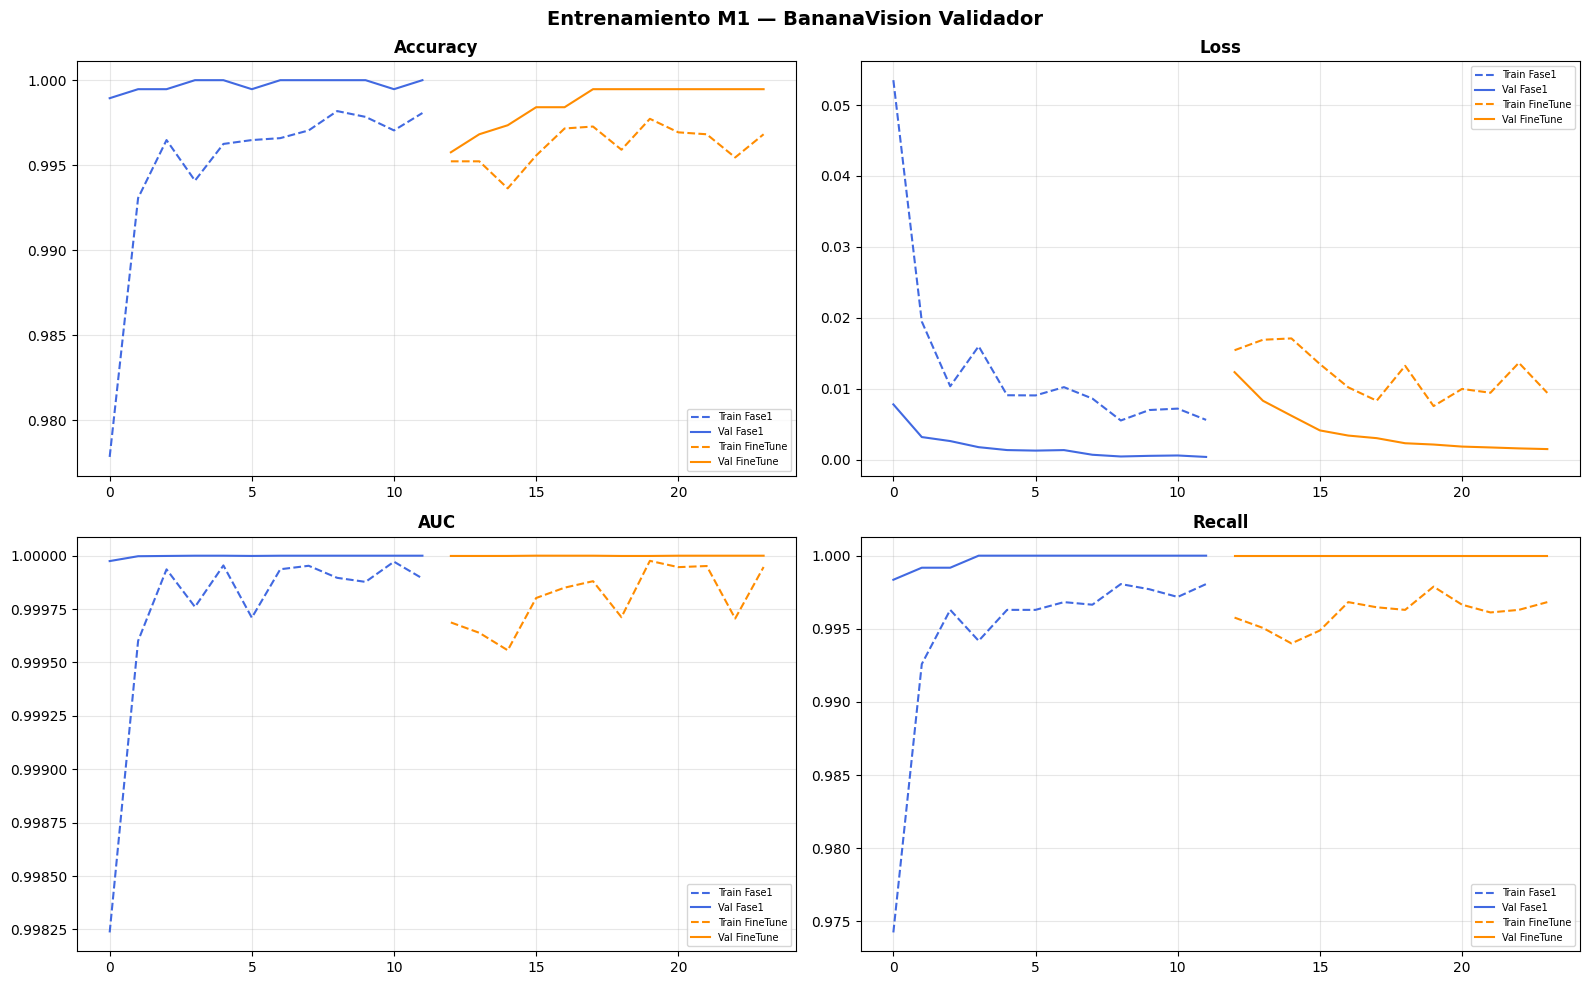

Curvas guardadas: C:\Users\Dell\Desktop\hackathon-sala\resultados\curvas_m1.png


In [14]:
def graficar(h1, h2):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle("Entrenamiento M1 — BananaVision Validador", fontsize=14, fontweight='bold')

    offset = len(h1.history['accuracy'])

    for hist, label, color in [(h1, "Fase1", "royalblue"), (h2, "FineTune", "darkorange")]:
        o = 0 if label == "Fase1" else offset
        ep = range(o, o + len(hist.history['accuracy']))
        for ax, key, title in zip(
            axes.flat,
            ['accuracy', 'loss', 'auc', 'recall'],
            ['Accuracy', 'Loss', 'AUC', 'Recall']
        ):
            ax.plot(ep, hist.history[key],            color=color, ls='--', label=f'Train {label}')
            ax.plot(ep, hist.history[f'val_{key}'],   color=color, ls='-',  label=f'Val {label}')
            ax.set_title(title, fontweight='bold')
            ax.legend(fontsize=7)
            ax.grid(alpha=0.3)

    plt.tight_layout()
    ruta = os.path.join(CFG["resultados_dir"], "curvas_m1.png")
    plt.savefig(ruta, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Curvas guardadas: {ruta}")

graficar(hist1, hist2)

## BLOQUE 12 — Evaluación completa

In [15]:

best_ckpt = CFG["modelo_best"].replace(".keras", "_fase2.keras")
modelo_eval = tf.keras.models.load_model(best_ckpt) if os.path.exists(best_ckpt) else modelo

val_gen.reset()
preds_raw = modelo_eval.predict(val_gen, verbose=1)   # Shape: (N, 1) — probabilidad non_leaf
y_pred    = (preds_raw.flatten() > 0.5).astype(int)   # 0=Leaf, 1=non_leaf
y_true    = val_gen.classes[:len(y_pred)]

print("\nClassification Report (Validación):")
print(classification_report(y_true, y_pred, target_names=CFG["clases"], digits=4))

try:
    auc_val = roc_auc_score(y_true, preds_raw.flatten())
    print(f"AUC (binario): {auc_val:.4f}")
except Exception as e:
    print(f"AUC: {e}")

59/59 [==============================] - 10s 125ms/step

Classification Report (Validación):
                 precision    recall  f1-score   support

    banana_leaf     1.0000    0.9955    0.9978       670
non_banana_leaf     0.9975    1.0000    0.9988      1215

       accuracy                         0.9984      1885
      macro avg     0.9988    0.9978    0.9983      1885
   weighted avg     0.9984    0.9984    0.9984      1885

AUC (binario): 1.0000


## BLOQUE 13 — Evaluación sobre test set

In [16]:
print("\n" + "=" * 55)
print("  EVALUACIÓN FINAL — TEST SET")
print("=" * 55)

test_gen.reset()
preds_test = modelo_eval.predict(test_gen, verbose=1)
y_pred_test = (preds_test.flatten() > 0.5).astype(int)
y_true_test = test_gen.classes[:len(y_pred_test)]

print("\nClassification Report (Test):")
print(classification_report(y_true_test, y_pred_test, target_names=CFG["clases"], digits=4))

try:
    auc_test = roc_auc_score(y_true_test, preds_test.flatten())
    print(f"AUC (test): {auc_test:.4f}")
except Exception as e:
    print(f"AUC: {e}")



  EVALUACIÓN FINAL — TEST SET
59/59 [==============================] - 34s 577ms/step

Classification Report (Test):
                 precision    recall  f1-score   support

    banana_leaf     1.0000    0.9940    0.9970       670
non_banana_leaf     0.9967    1.0000    0.9984      1215

       accuracy                         0.9979      1885
      macro avg     0.9984    0.9970    0.9977      1885
   weighted avg     0.9979    0.9979    0.9979      1885

AUC (test): 1.0000


## BLOQUE 14 — Matriz de Confusión

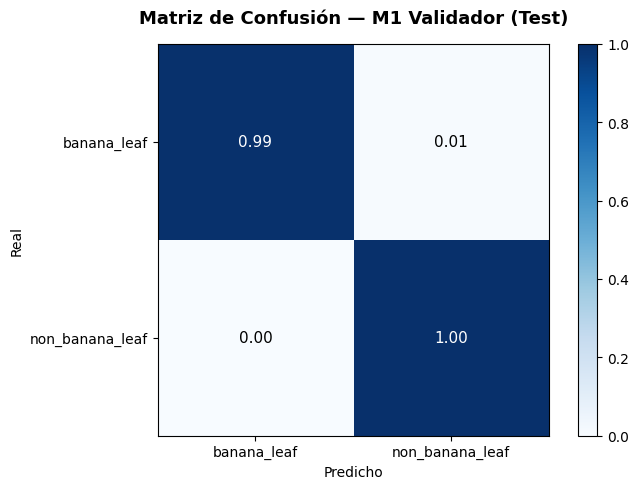

Matriz guardada: C:\Users\Dell\Desktop\hackathon-sala\resultados\confusion_m1.png


In [17]:
cm = confusion_matrix(y_true_test, y_pred_test, normalize='true')

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
fig.colorbar(im, ax=ax)
ax.set(
    xticks=np.arange(len(CFG["clases"])),
    yticks=np.arange(len(CFG["clases"])),
    xticklabels=CFG["clases"],
    yticklabels=CFG["clases"],
    ylabel='Real',
    xlabel='Predicho',
)
thresh = cm.max() / 2.0
for i, j in itertools.product(range(len(CFG["clases"])), range(len(CFG["clases"]))):
    ax.text(j, i, f'{cm[i,j]:.2f}',
            ha='center', va='center', fontsize=11,
            color='white' if cm[i,j] > thresh else 'black')

ax.set_title('Matriz de Confusión — M1 Validador (Test)', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()

ruta = os.path.join(CFG["resultados_dir"], "confusion_m1.png")
plt.savefig(ruta, dpi=150, bbox_inches='tight')
plt.show()
print(f"Matriz guardada: {ruta}")


## BLOQUE 14 — Función de inferencia para producción

In [18]:
UMBRAL_CONFIANZA = 0.6

def predecir_m1(ruta_imagen: str, modelo=modelo_eval) -> dict:
    """
    Determina si una imagen es una hoja de banano válida.

    Returns:
        {
            "es_banano": bool,
            "confianza": float,   # confianza en la clase predicha
            "clase": str,         # "Leaf" o "non_leaf"
        }
    """
    img = tf.keras.utils.load_img(ruta_imagen, target_size=CFG["img_size"])
    arr = tf.keras.utils.img_to_array(img)
    arr = preprocess_input(arr)
    arr = np.expand_dims(arr, axis=0)

    prob_nonleaf = float(modelo.predict(arr, verbose=0)[0][0])
    prob_leaf    = 1.0 - prob_nonleaf

    es_banano = prob_nonleaf < UMBRAL_CONFIANZA
    clase     = "Leaf" if es_banano else "non_leaf"
    confianza = prob_leaf if es_banano else prob_nonleaf

    print("\n" + "═" * 45)
    print("  DIAGNÓSTICO M1 — Validador de Imagen")
    print("═" * 45)
    print(f"  Resultado  : {'✓ Es hoja de banano' if es_banano else '✗ No es hoja de banano'}")
    print(f"  Clase      : {clase}")
    print(f"  Confianza  : {confianza * 100:.1f}%")
    print(f"  P(Leaf)    : {prob_leaf * 100:.1f}%")
    print(f"  P(non_leaf): {prob_nonleaf * 100:.1f}%")
    print("═" * 45)

    return {
        "es_banano": es_banano,
        "clase":     clase,
        "confianza": confianza,
    }